In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Now get the vertical profiles

In [2]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['dissic']#['tas','tos','fgco2','nbp','intpp','npp','cSoil','intdic']#'cLand','cVeg'['tos','fgco2','intpp','intdic','tas','cLand','cSoil','cVeg','npp','nbp']#['intdic']#['dissic']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #[,'tas'] #['intdic']#['cLand','cSoil','cVeg','tos','nbp','fgco2','npp','intpp','tas']#'dissic'] #['tas']#['dissic']##['cVeg']#'tas','tos', #['tas','tos', #'tas', #['npp']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM']#['GISSE2.1-G-CC2']#['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1'] #['UKESM1-2']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#[]#['ACCESS-ESM1-5']#['CESM2']#['MIROC-ES2L']#['ACCESS-ESM1-5']#['UKESM1-2']#['EC-Earth3-ESM-1'] #['NorESM2-LM']#['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['NorESM2-LM']##['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['CESM2']#['ACCESS-ESM1-5'] #['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[1:]#:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

stat = 'integral'
temporal_stat = 'mean'

# choose the type of temporal statisic
temporal_stats = ['mean'] # 'std', 'linear trend', 
# choose the time window length (in years) for rolling_mean
rm_window = 31 # in years
# choose the time_window_size for tim slices
time_window_size = 21 # in years
# choose the reference 
reference = 'first_year_of_rampup' # 'first_year_of_piC', 'first_10y_of_rampup', ...
# choose GMST levels at which to calculate time slice maps (for rampup and rampdown). For the piC, and stabilizations, I calculate the time slice statistic over the first time_window_size years
#gmst_levels = [0,1,2,3,4]

#server='spirit' # 'cineca'#
outroot = './../01_postprocessed_data/vertical_profiles/'

ZECs = [0,10,25,50,100,150,200]#,250,300]

# Define the runs_to_analyse
run_names = ['esm-piControl',
             'esm-up2p0-gwl2p0',
             'esm-up2p0-gwl4p0',
             'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'
            ]


def get_time_range_underlying_time_slice(model,run_name,zec_horizon,time_window_size,temporal_stat):    #,running_mean_years=31,centered_running_mean=True,reference_slice='jones2025'):

    # get the model_dict for extra info
    model_dict = pmods.get_model_dict('all')

    
    if temporal_stat == 'mean':
    
        # half_window
        half_window = int((time_window_size-1)/2)
        if zec_horizon == 0:
            half_window = 0 
        
        if run_name == 'esm-piControl':
            if model == 'ACCESS-ESM1-5':
                time_slice_start_year = 271 #model_dict[model].rampup_start_year
                time_slice_end_year = 271+time_window_size-1 #model_dict[model].rampup_start_year+time_window_size-1 
            else:
                time_slice_start_year = model_dict[model].rampup_start_year + zec_horizon - half_window
                time_slice_end_year = model_dict[model].rampup_start_year + zec_horizon + half_window
        elif run_name == 'esm-up2p0-gwl2p0':
            time_slice_start_year = model_dict[model].stab2K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].stab2K_start_year + zec_horizon + half_window #  last (time_window_size)years of the stabilization before rampdown
        elif run_name == 'esm-up2p0-gwl4p0':
            time_slice_start_year = model_dict[model].stab4K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].stab4K_start_year + zec_horizon + half_window  #  last (time_window_size)years of the stabilization before rampdown
        elif run_name == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
            time_slice_start_year = model_dict[model].restab2K_start_year + zec_horizon - half_window
            time_slice_end_year = model_dict[model].restab2K_start_year + zec_horizon + half_window   #  last (time_window_size)years of the restabilization
    
        # turn nan years into None
        print(time_slice_start_year)
        print(time_slice_end_year)
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
        print(time_slice_start_year)
        print(time_slice_end_year)

    elif temporal_stat == 'linear_trend':

        if run_name == 'esm-piControl':
            if model == 'ACCESS-ESM1-5':
                time_slice_start_year = 271 #model_dict[model].rampup_start_year
                time_slice_end_year = 271+zec_horizon #model_dict[model].rampup_start_year+time_window_size-1 
            else:
                time_slice_start_year = model_dict[model].rampup_start_year
                time_slice_end_year = model_dict[model].rampup_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl2p0':
            time_slice_start_year = model_dict[model].stab2K_start_year
            time_slice_end_year = model_dict[model].stab2K_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl4p0':
            time_slice_start_year = model_dict[model].stab4K_start_year
            time_slice_end_year = model_dict[model].stab4K_start_year + zec_horizon - 1
        elif run_name == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
            time_slice_start_year = model_dict[model].restab2K_start_year
            time_slice_end_year = model_dict[model].restab2K_start_year + zec_horizon - 1

        # turn nan years into None
        print(time_slice_start_year)
        print(time_slice_end_year)
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
        if time_slice_end_year == time_slice_start_year - 1:
            time_slice_end_year = time_slice_start_year
        print(time_slice_start_year)
        print(time_slice_end_year)
    
    return time_slice_start_year, time_slice_end_year



def calc_time_slice_stat(varia,model,run,ZEC,time_slice_start_year,time_slice_end_year,temporal_stat='mean',vert_stat=None):

    if model == 'CESM2':
        print(varia)
        varia = mgrab.varia_mapper_cmor_to_model(varia)
        print(varia)
                
    # first get the dataset
    #da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=0)#,server=server)#,server=server)
    save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_integral'
    save_string = f'{varia}_{model}_{run}_{member}_global_integral.nc'
    da = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
    print(f'... loading {da.time.size} data points in time.')


    if model == 'CESM2' and varia == 'TEMP':
        print('choosing only the shallowest layer')
        da = da.isel(z_t=0)#.squeeze().persist()
        print(da)

    # make sure the time dimension is Proleptic Gregorian
    da = TimeOperator.shift_time_axis_by_n_years(da,n=0)
    
    # get unit
    #unit = da.units
    
    # resample to annual means
    da_annual = da.resample(time='1YS').mean(dim='time') # weight with month lengths?
    #print(da_annual.time)

    # cut out the time slice
    #da_annual_slice = da_annual.sel(time=slice(cftime.DatetimeProlepticGregorian(time_slice_start_year,1,1),cftime.DatetimeProlepticGregorian(time_slice_end_year,1,1)))

    if time_slice_start_year is None or time_slice_end_year is None:
    
        da_annual_slice = xr.full_like(
            da_annual.isel(time=slice(0, 2)).astype(float),
            np.nan,
        )

    elif time_slice_start_year == time_slice_end_year and temporal_stat == 'linear_trend':
        da_annual_slice = xr.full_like(
            da_annual.isel(time=slice(0, 2)).astype(float),
            np.nan,
        )        
    
    else:
        da_annual_slice = da_annual.sel(
            time=slice(
                cftime.DatetimeProlepticGregorian(time_slice_start_year, 1, 1),
                cftime.DatetimeProlepticGregorian(time_slice_end_year, 1, 1),
            )
        )

    if temporal_stat == 'mean':
        temp_statistic = da_annual_slice.mean(dim='time')
        #unit = unit
    else:
        raise Exception('This temporal_stat is not yet defined.')
    
    return temp_statistic 
    

In [3]:
sdict = dict()
dzdict = dict()

for varia in varias:
    sdict[varia] = dict()
    dzdict[varia] = dict()
    
    for model in models:
        
        mgrab = MODELgrabber.get_grabber(model)

        print(f'---{model}---')

        temporal_stat_dict = {}

        ds = xr.Dataset()

        # store bounds for all runs
        run_start_years = {}
        run_end_years = {}

        for run in run_names:
            
            print(f'--- run: {run} ---')
            member = mgrab.get_member()#run)

            
            statistic_all = []
            start_years = []
            end_years = []

            for ZEC in ZECs:
                print(
                    f'-> calculate time slice statistic(s) for '
                    f'{varia}, {model}, {run}, {ZEC} year ZEC.'
                )

                time_slice_start_year, time_slice_end_year = (
                    get_time_range_underlying_time_slice(
                        model,
                        run,
                        ZEC,
                        time_window_size,
                        temporal_stat
                    )
                )

                print(
                    '... time range:',
                    time_slice_start_year,
                    time_slice_end_year
                )

                print(f'    ... computing {temporal_stat}')

                statistic = (
                    calc_time_slice_stat(
                        varia,
                        model,
                        run,
                        ZEC,
                        time_slice_start_year,
                        time_slice_end_year,
                        temporal_stat=temporal_stat,
                    )
                )

                # store time window information
                start_years.append(
                    np.nan if time_slice_start_year is None
                    else time_slice_start_year
                )
    
                end_years.append(
                    np.nan if time_slice_end_year is None
                    else time_slice_end_year
                )
    
                # add ZEC dimension
                statistic = statistic.expand_dims(
                    ZEC=[ZEC]
                )
    
                statistic_all.append(
                    statistic
                )
    
            # combine all ZEC values for this run
            da = xr.concat(
                statistic_all,
                dim="ZEC"
            )
    
            # add as variable in Dataset
            ds[run] = da[f'{varia}_global_{stat}'].astype('float32')
    
            # store run-dependent bounds
            run_start_years[run] = start_years
            run_end_years[run] = end_years
    
    
        # Add run dimension to Dataset
        ds = ds.assign_coords(
            run=("run", run_names)
        )
    
        # Convert stored bounds to arrays
        start_year_array = np.array(
            [
                run_start_years[run]
                for run in run_names
            ]
        )
    
        end_year_array = np.array(
            [
                run_end_years[run]
                for run in run_names
            ]
        )
    
        # Add run-dependent ZEC coordinates
        ds["ZEC_start_year"] = (
            ("run", "ZEC"),
            start_year_array
        )
    
        ds["ZEC_end_year"] = (
            ("run", "ZEC"),
            end_year_array
        )
    
        # Global attributes
        ds.attrs = {
            "title": f"Global time slice {temporal_stat}s",
            "model": model,
            "member": member,
            "varia": varia,
            "freq_input": freq_input,
            "temporal_stat": temporal_stat,
            "time_window_size": time_window_size,
            "outroot": outroot,
            #"unit": unit,
            "author": "E. E. Köhn",
            "created": "2026-05-20",
        }

        sdict[varia][model] = ds

        dzdict[varia][model] = mgrab.get_dz(varia,run,freq_input=freq_input,verbose_level=0)

---IPSL-CM6-ESMCO2---
--- run: esm-piControl ---
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, esm-piControl, 0 year ZEC.
1850
1850
1850
1850
... time range: 1850 1850
    ... computing mean
... loading 7788 data points in time.
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, esm-piControl, 10 year ZEC.
1850
1870
1850
1870
... time range: 1850 1870
    ... computing mean
... loading 7788 data points in time.
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, esm-piControl, 25 year ZEC.
1865
1885
1865
1885
... time range: 1865 1885
    ... computing mean
... loading 7788 data points in time.
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, esm-piControl, 50 year ZEC.
1890
1910
1890
1910
... time range: 1890 1910
    ... computing mean
... loading 7788 data points in time.
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, esm-piControl, 100 year ZEC.
1940
1960
1940
1960
... time range: 1940 1960
    ...

In [4]:
model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

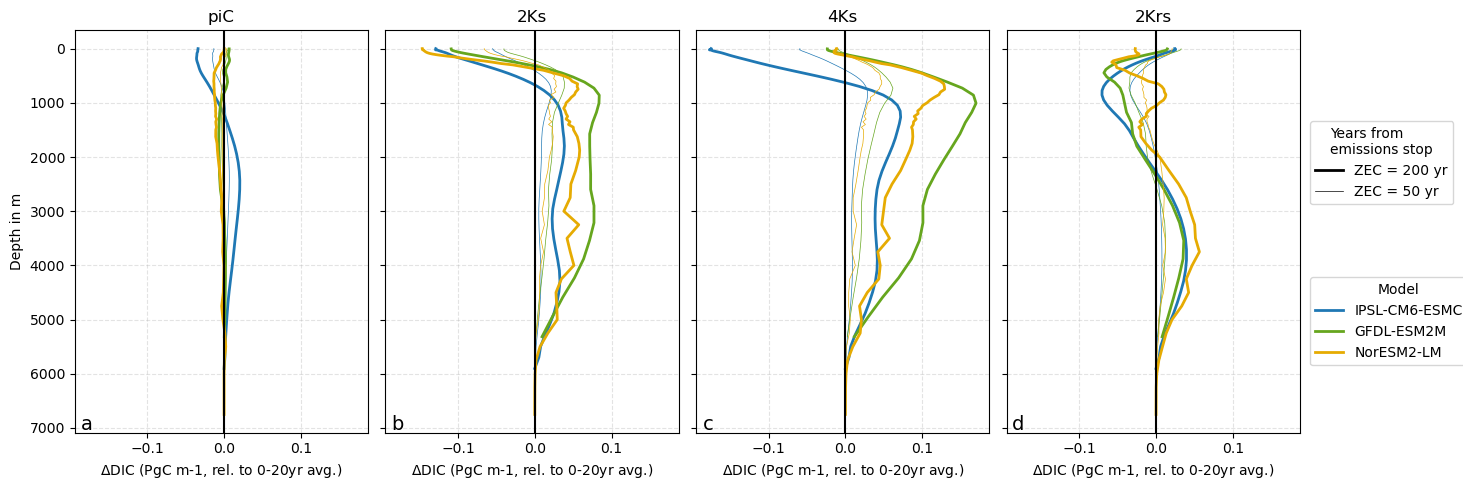

In [36]:
from matplotlib.lines import Line2D

col_labels = ["piC", "2Ks", "4Ks", "2Krs"]

for varia in varias:
    fig, ax = plt.subplots(1,len(run_names),figsize=(15,5),sharex=True,sharey=True)
    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        for rdx,run in enumerate(run_names):
            ref_profile = sdict['dissic'][model][run].sel(ZEC=10)
            for zdx,ZEC in enumerate([200,50]): #[25,50,100,150,200]:
                profile = (sdict['dissic'][model][run].sel(ZEC=ZEC) - ref_profile) / dzdict['dissic'][model]
                profile = profile * 12.0107/1000/1000/1000/1000/1000
                if zdx == 0 and run == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
                    label = model
                else:
                    label = ''
                ax[rdx].plot(profile,profile[zlev],color=model_dict[model].color_id,linestyle='-',linewidth=ZEC/100,label=label)#run_dict[run].linestyle_id)
    for rdx,run in enumerate(run_names):
        ax[rdx].grid(alpha=0.35,linestyle='--',zorder=-10)
        ax[rdx].set_title(col_labels[rdx])
        ax[rdx].axvline(0,color='k')
        ax[rdx].set_xlabel(f'$\Delta$DIC (PgC m-1, rel. to 0-20yr avg.)')
ax[0].set_ylabel('Depth in m')
ax[0].invert_yaxis()
plt.tight_layout()
plt.subplots_adjust(right=0.87)
ax[-1].legend(loc='lower left',bbox_to_anchor=(1.01,0.1))


labels = ['a','b','c','d']
for adx,axi in enumerate(ax):
    xpos = 0.04
    axi.text(xpos,0.02,labels[adx],ha='center',va='center',transform=axi.transAxes,fontsize=14)

# Existing model legend
model_handles = [
    Line2D([0], [0],
           color=model_dict[model].color_id,
           lw=2,
           label=model)
    for model in models
]

# ZEC legend (matching the linewidths used in the plots)
zec_values = [200, 50]
zec_handles = [
    Line2D([0], [0],
           color='k',
           lw=zec/100,
           label=f'ZEC = {zec} yr')
    for zec in zec_values
]

# Add legends
leg1 = ax[-1].legend(handles=model_handles,
                     title='Model',
                     loc='lower left',
                     bbox_to_anchor=(1.01, 0.15))

leg2 = ax[-1].legend(handles=zec_handles,
                     title='Years from\nemissions stop',
                     loc='lower left',
                     bbox_to_anchor=(1.01, 0.55))

# Keep both
ax[-1].add_artist(leg1)
plot_dir = f'./../03_plots/vertical_profile_global_{stat}_ZEC/{varia}/win_21yr/{temporal_stat}'
os.makedirs(plot_dir,exist_ok = True)
plot_filename = f'{varia}_vert_profile_MMM_{temporal_stat}_win21yr.png'
fig.savefig(f'{plot_dir}/{plot_filename}',dpi=300) # ,transparent=True


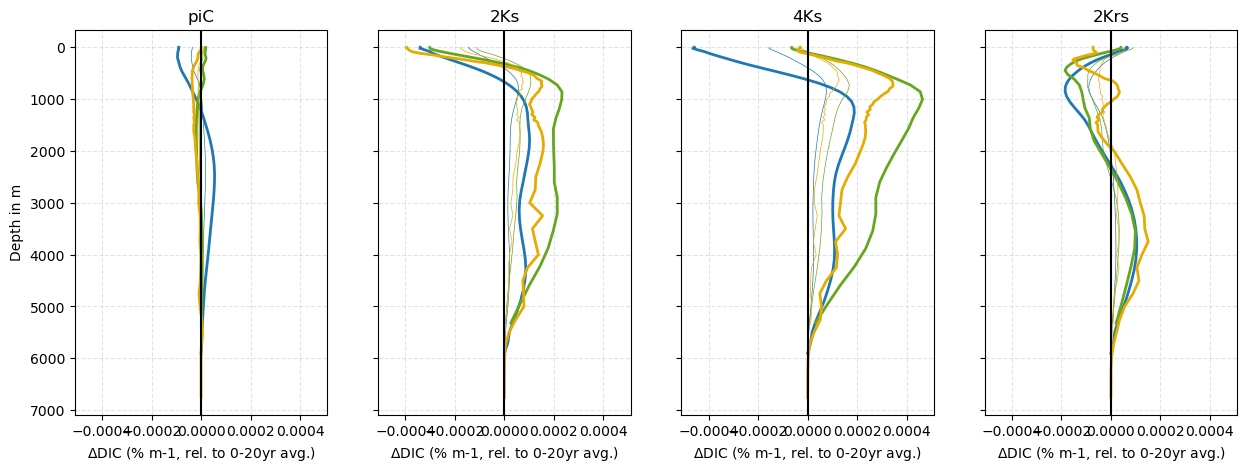

In [13]:
col_labels = ["piC", "2Ks", "4Ks", "2Krs"]

for varia in varias:
    fig, ax = plt.subplots(1,len(run_names),figsize=(15,5),sharex=True,sharey=True)
    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        for rdx,run in enumerate(run_names):
            dz = dzdict['dissic'][model]
            ref_profile = sdict['dissic'][model][run].sel(ZEC=10)/dz
            ref_profile_sum = (ref_profile*dz).sum(zlev)
            rel_ref_profile = ref_profile / ref_profile_sum * 100 # in % m-1

            for ZEC in [50,200]: #[25,50,100,150,200]:
                dz = dzdict['dissic'][model]
                profile = sdict['dissic'][model][run].sel(ZEC=ZEC)/dz # in PgC m-1
                rel_profile = profile / ref_profile_sum * 100 # in % m-1

                anom_profile = rel_profile - rel_ref_profile

                ax[rdx].plot(anom_profile,anom_profile[zlev],color=model_dict[model].color_id,linestyle='-',linewidth=ZEC/100)#run_dict[run].linestyle_id)
    for rdx,run in enumerate(run_names):
        ax[rdx].grid(alpha=0.35,linestyle='--',zorder=-10)
        ax[rdx].set_title(col_labels[rdx])
        ax[rdx].axvline(0,color='k')
        ax[rdx].set_xlabel(f'$\Delta$DIC (% m-1, rel. to 0-20yr avg.)')
ax[0].set_ylabel('Depth in m')
ax[0].invert_yaxis()


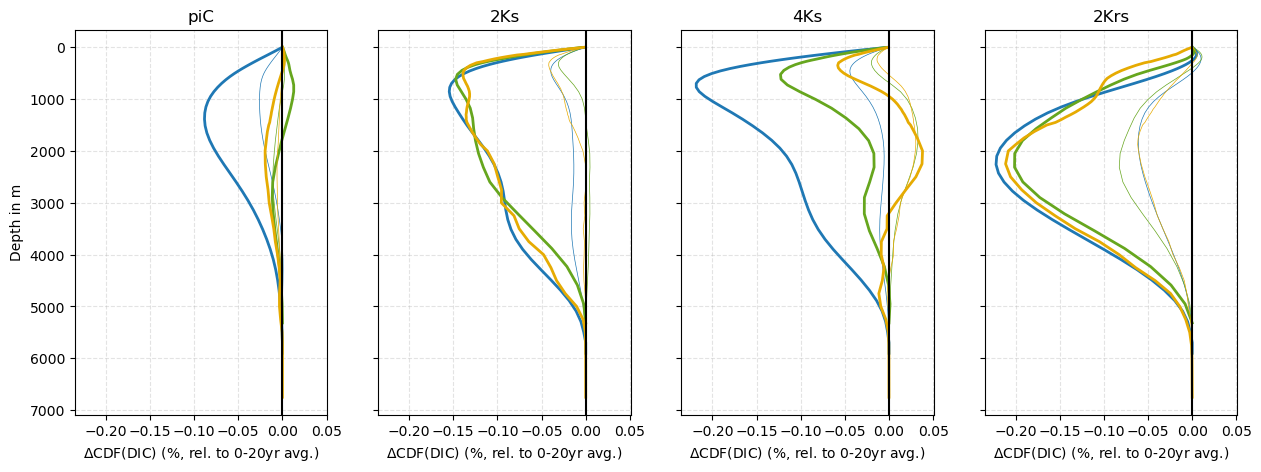

In [16]:
col_labels = ["piC", "2Ks", "4Ks", "2Krs"]

for varia in varias:
    fig, ax = plt.subplots(1,len(run_names),figsize=(15,5),sharex=True,sharey=True)
    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        for rdx,run in enumerate(run_names):
            dz = dzdict['dissic'][model]
            ref_profile = sdict['dissic'][model][run].sel(ZEC=10)
            ref_profile_cumsum = ref_profile.cumsum(zlev) / (ref_profile).sum(zlev) * 100 

            for ZEC in [50,200]: #[25,50,100,150,200]:
                profile = sdict['dissic'][model][run].sel(ZEC=ZEC)
                profile_cumsum = profile.cumsum(zlev) / (profile).sum(zlev) * 100 

                anom_profile = profile_cumsum - ref_profile_cumsum

                ax[rdx].plot(anom_profile,anom_profile[zlev],color=model_dict[model].color_id,linestyle='-',linewidth=ZEC/100)#run_dict[run].linestyle_id)
    for rdx,run in enumerate(run_names):
        ax[rdx].grid(alpha=0.35,linestyle='--',zorder=-10)
        ax[rdx].set_title(col_labels[rdx])
        ax[rdx].axvline(0,color='k')
        ax[rdx].set_xlabel(f'$\Delta$CDF(DIC) (%, rel. to 0-20yr avg.)')
ax[0].set_ylabel('Depth in m')
ax[0].invert_yaxis()
